In [3]:
from pathlib import Path

import pandas as pd

pd.set_option("display.max_columns", None)

# Walk up from the current folder until we find pyproject.toml = project root
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
print("Project root:", ROOT)

df = pd.read_csv(ROOT / "data" / "raw" / "telco_churn.csv")
df.head()

Project root: /Users/eldwiny/projects/churn-predictor


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [10]:
tc = pd.to_numeric(df["TotalCharges"], errors="coerce")
bad = df[tc.isna()]
print(len(bad))
bad[["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]


11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [11]:
print(bad["TotalCharges"].map(repr).unique())

["' '"]


In [12]:
cat_cols = df.select_dtypes("object").columns.drop(["customerID", "TotalCharges"])
for c in cat_cols:
    print(c, df[c].unique().tolist())

gender ['Female', 'Male']
Partner ['Yes', 'No']
Dependents ['No', 'Yes']
PhoneService ['No', 'Yes']
MultipleLines ['No phone service', 'No', 'Yes']
InternetService ['DSL', 'Fiber optic', 'No']
OnlineSecurity ['No', 'Yes', 'No internet service']
OnlineBackup ['Yes', 'No', 'No internet service']
DeviceProtection ['No', 'Yes', 'No internet service']
TechSupport ['No', 'Yes', 'No internet service']
StreamingTV ['No', 'Yes', 'No internet service']
StreamingMovies ['No', 'Yes', 'No internet service']
Contract ['Month-to-month', 'One year', 'Two year']
PaperlessBilling ['Yes', 'No']
PaymentMethod ['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)']
Churn ['No', 'Yes']


In [13]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [14]:
d = df.copy()
d["TotalCharges"] = pd.to_numeric(d["TotalCharges"], errors="coerce").fillna(0.0)
d["churn"] = (d["Churn"] == "Yes").astype(int)
d["churn"].mean()

np.float64(0.2653698707936959)

In [15]:
cats = d.select_dtypes("object").columns.drop(["customerID", "Churn"])
for c in cats:
    print(d.groupby(c)["churn"].mean().sort_values(ascending=False).round(3), "\n")

gender
Female    0.269
Male      0.262
Name: churn, dtype: float64 

Partner
No     0.330
Yes    0.197
Name: churn, dtype: float64 

Dependents
No     0.313
Yes    0.155
Name: churn, dtype: float64 

PhoneService
Yes    0.267
No     0.249
Name: churn, dtype: float64 

MultipleLines
Yes                 0.286
No                  0.250
No phone service    0.249
Name: churn, dtype: float64 

InternetService
Fiber optic    0.419
DSL            0.190
No             0.074
Name: churn, dtype: float64 

OnlineSecurity
No                     0.418
Yes                    0.146
No internet service    0.074
Name: churn, dtype: float64 

OnlineBackup
No                     0.399
Yes                    0.215
No internet service    0.074
Name: churn, dtype: float64 

DeviceProtection
No                     0.391
Yes                    0.225
No internet service    0.074
Name: churn, dtype: float64 

TechSupport
No                     0.416
Yes                    0.152
No internet service    0.074
Name:

Matplotlib is building the font cache; this may take a moment.


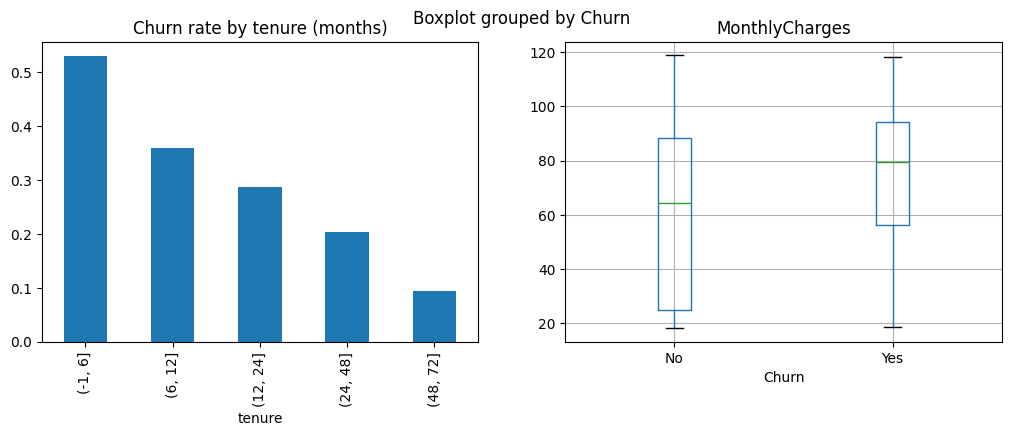

In [16]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
d.groupby(pd.cut(d["tenure"], [-1, 6, 12, 24, 48, 72]), observed=True)["churn"].mean().plot.bar(ax=ax[0], title="Churn rate by tenure (months)")
d.boxplot(column="MonthlyCharges", by="Churn", ax=ax[1])
plt.show()

In [17]:
diff = (d["tenure"] * d["MonthlyCharges"] - d["TotalCharges"]).abs()
print(diff.describe())

count    7043.000000
mean       45.018735
std        49.892509
min         0.000000
25%         9.350000
50%        28.600000
75%        63.625000
max       373.250000
dtype: float64


In [18]:
rows = []
for c in cats:
    r = d.groupby(c)["churn"].mean()
    rows.append((c, r.max() - r.min(), r.idxmax(), r.max(), r.idxmin(), r.min()))
pd.DataFrame(rows, columns=["feature", "gap", "highest_group", "highest_rate", "lowest_group", "lowest_rate"]).sort_values("gap", ascending=False).round(3)

,feature,gap,highest_group,highest_rate,lowest_group,lowest_rate
12,Contract,0.399,Month-to-month,0.427,Two year,0.028
5,InternetService,0.345,Fiber optic,0.419,No,0.074
6,OnlineSecurity,0.344,No,0.418,No internet service,0.074
9,TechSupport,0.342,No,0.416,No internet service,0.074
7,OnlineBackup,0.325,No,0.399,No internet service,0.074
8,DeviceProtection,0.317,No,0.391,No internet service,0.074
14,PaymentMethod,0.300,Electronic check,0.453,Credit card (automatic),0.152
11,StreamingMovies,0.263,No,0.337,No internet service,0.074
10,StreamingTV,0.261,No,0.335,No internet service,0.074
13,PaperlessBilling,0.172,Yes,0.336,No,0.163


In [19]:
net = d[d["InternetService"] != "No"]
for c in ["OnlineSecurity", "TechSupport"]:
    print(net.groupby(c)["churn"].mean().round(3), "\n")
print(d.groupby("Contract")["tenure"].mean().round(1))

OnlineSecurity
No     0.418
Yes    0.146
Name: churn, dtype: float64 

TechSupport
No     0.416
Yes    0.152
Name: churn, dtype: float64 

Contract
Month-to-month    18.0
One year          42.0
Two year          56.7
Name: tenure, dtype: float64


In [20]:
net = d[d["InternetService"] != "No"]
for c in ["OnlineSecurity", "TechSupport"]:
    print(net.groupby(c)["churn"].mean().round(3), "\n")
print(d.groupby("Contract")["tenure"].mean().round(1))

OnlineSecurity
No     0.418
Yes    0.146
Name: churn, dtype: float64 

TechSupport
No     0.416
Yes    0.152
Name: churn, dtype: float64 

Contract
Month-to-month    18.0
One year          42.0
Two year          56.7
Name: tenure, dtype: float64


In [21]:
d["tenure_bin"] = pd.cut(d["tenure"], [-1, 12, 24, 48, 72])
d.pivot_table(index="tenure_bin", columns="Contract", values="churn", aggfunc="mean", observed=True).round(3)

Contract,Month-to-month,One year,Two year
tenure_bin,,,
"(-1, 12]",0.514,0.105,0.000
"(12, 24]",0.377,0.081,0.000
"(24, 48]",0.329,0.106,0.022
"(48, 72]",0.260,0.129,0.033
